### Stage 1: Filter Sweep

Here we look at a range of filter sizes for different algorithms and different types of filter. 

Results used here that were produced by running ```scripts/```:
- `filter_sweep_single_state.py`
- `filter_sweep_multi_state.py`


# TODO:

* Fix random filter - size not correct **(random.choices uses replacement! - check where else in ABM code this is used).**
* Check GRASP and RLD2. Especially with the ML filter. Why not better at low FS?
* Try running computational resource tests/sweeps at different/low filter sizes for GRASP and RLD2 - do these stochastic algorithms start to find the Greedy solution?!

1. As part of hypertuning: change `ORandom` settings: currently returning invalid teams too often due to timeout.
2. Check alterations to RLD2 - currently returning invalid teams also.

In [1]:
import pandas as pd
import pickle
import numpy as np
import superscript_abm

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def load_results(path):
    with open(path, 'rb') as infile:
        results = pickle.load(infile)
        
    return results

In [3]:
def get_prob(results, algo='random'):
    return [
        results[algo][k]['probability'][0]
        for k in results[algo].keys() 
    ]

def get_runtime(results, algo='random'):
    return [
        results[algo][k]['runtime'][0]
        for k in results[algo].keys() 
    ]

## Next we look at multi-state results for a more comprehensive picture:

#### Note: I have removed the first_n filter results for now because we decided not to include them in the article. But there was evidence of ordering effects, which could be something to invetigate in 'stage 2'.

In [4]:
# ml_filter_results = load_results('../stage_1_results/filter_sweep_multi_state/exp_2_run_1/results.pickle')
# ml_filter_results_2 = load_results('../stage_1_results/filter_sweep_multi_state/exp_2_run_2/results.pickle')
# for key in ml_filter_results_2.keys():
#     ml_filter_results[key] = ml_filter_results_2[key]

ml_filter_results = load_results('../stage_1_results/filter_sweep_multi_state/exp_13_run_1/results.pickle')

In [40]:
# ml_filter_results_2 = load_results('../stage_1_results/filter_sweep_multi_state/exp_7_run_1/results.pickle')
# for key in ml_filter_results_2.keys():
#     ml_filter_results[key] = ml_filter_results_2[key]

In [53]:
# ml_filter_results_2 = load_results('../stage_1_results/filter_sweep_multi_state/exp_8_run_1/results.pickle')
# for key in ml_filter_results_2.keys():
#     ml_filter_results[key] = ml_filter_results_2[key]

In [55]:
ml_filter_results.keys()

dict_keys(['random', 'linear', 'greedy', 'grasp', 'rld2_10', 'rld2_100', 'rld2_1000', 'rld2_v3', 'rld2_v3_10', 'rld2_v3_100', 'rld2_v3_100_rld1_10', 'rld2_v3_10_rld1_10'])

In [48]:
# random_filter_results = load_results('../stage_1_results/filter_sweep_multi_state/exp_3_run_2/results.pickle')
# random_filter_results_2 = load_results('../stage_1_results/filter_sweep_multi_state/exp_3_run_4/results.pickle')
# for key in random_filter_results_2.keys():
#     random_filter_results[key] = random_filter_results_2[key]

random_filter_results = load_results('../stage_1_results/filter_sweep_multi_state/exp_12_run_1/results.pickle')
# for key in random_filter_results_2.keys():
#     random_filter_results[key] = random_filter_results_2[key]

In [49]:
# random_filter_results_2 = load_results('../stage_1_results/filter_sweep_multi_state/exp_9_run_1/results.pickle')
# for key in random_filter_results_2.keys():
#     random_filter_results[key] = random_filter_results_2[key]

In [84]:
stoch_rld1_results = load_results('../stage_1_results/filter_sweep_multi_state/exp_4_run_1/results.pickle')
stoch_rld1_results_2 = load_results('../stage_1_results/filter_sweep_multi_state/exp_5_run_1/results.pickle')
stoch_rld1_results_3 = load_results('../stage_1_results/filter_sweep_multi_state/exp_6_run_1/results.pickle')

In [87]:
for alg in stoch_rld1_results_2.keys():
    for state in stoch_rld1_results_2[alg].keys():
        stoch_rld1_results_2[alg][state].update(stoch_rld1_results_3[alg][state])

In [88]:
stoch_rld1_results = load_results('../stage_1_results/filter_sweep_multi_state/exp_4_run_1/results.pickle')
for key in stoch_rld1_results_2.keys():
    stoch_rld1_results[key] = stoch_rld1_results_2[key]

In [64]:
# stoch_rld1_results['rld2_10_rld1_100']

In [54]:
def extract_mean_std(
    rdf, algo='random', 
    filter_sizes=[10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    fields=['probability', 'runtime', 'team_size'],
    remove_none=True,
    verbose=False
):
    print(f"Algo: {algo}")
    states = rdf[algo].keys()
    
    extract = {
        'filter_size': filter_sizes,
        'mean_probability': [],
        'std_probability': [],
        'mean_runtime': [],
        'std_runtime': [],
        'mean_team_size': [],
        'std_team_size': []
    }
    for field in fields:
        for fs in filter_sizes:
    
            if remove_none:
                raw = [
                    rdf[algo][state][fs][field] [0]
                    for state in states
                    if (
                        len(rdf[algo][state][fs][field])>0
                        and rdf[algo][state][fs][field][0] is not None
                    )
                ]
            else:
                raw = [
                    rdf[algo][state][fs][field] [0]
                    if (
                        len(rdf[algo][state][fs][field])>0
                        and rdf[algo][state][fs][field][0] is not None
                    )
                    else 0
                    for state in states
                ]
            extract[f'mean_{field}'].append(np.mean(raw))
            extract[f'std_{field}'].append(np.std(raw))
            
            
            none_count = [
                1
                for state in states
                if (
                        len(rdf[algo][state][fs][field])>0
                        and rdf[algo][state][fs][field][0] is not None
                    )
            ]
            if verbose:
                print(f"FS: {fs}, field: {field}, None count: {sum(none_count)}")
        
    
    return pd.DataFrame(extract)
    

In [10]:
def means_stds_dict(_results, algos=None, filter_sizes=[10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
):
    if algos is None:
        algos = _results.keys()
        
    return {
        algo: extract_mean_std(rdf=_results, algo=algo, filter_sizes=filter_sizes)
        for algo in algos
    }

In [56]:
ml_filter_ms = means_stds_dict(ml_filter_results, filter_sizes=[10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
# ml_filter_ms = means_stds_dict(ml_filter_results)

Algo: random
Algo: linear
Algo: greedy
Algo: grasp


In [50]:
random_filter_ms = means_stds_dict(random_filter_results, filter_sizes=[10, 20, 30, 40, 50, 60, 70, 80, 90, 100])

Algo: random
Algo: linear
Algo: greedy
Algo: grasp


In [138]:
stoch_rld1_ms = means_stds_dict(stoch_rld1_results, filter_sizes=[10, 100])

Algo: rld2_10_rld1_10
Algo: rld2_1_rld1_100
Algo: rld2_1_rld1_1
Algo: rld2_1_rld1_10
Algo: rld2_10_rld1_100
Algo: rld2_100_rld1_10
Algo: rld2_1000_rld1_10
Algo: rld2_1000_rld1_100


##### Random filter:

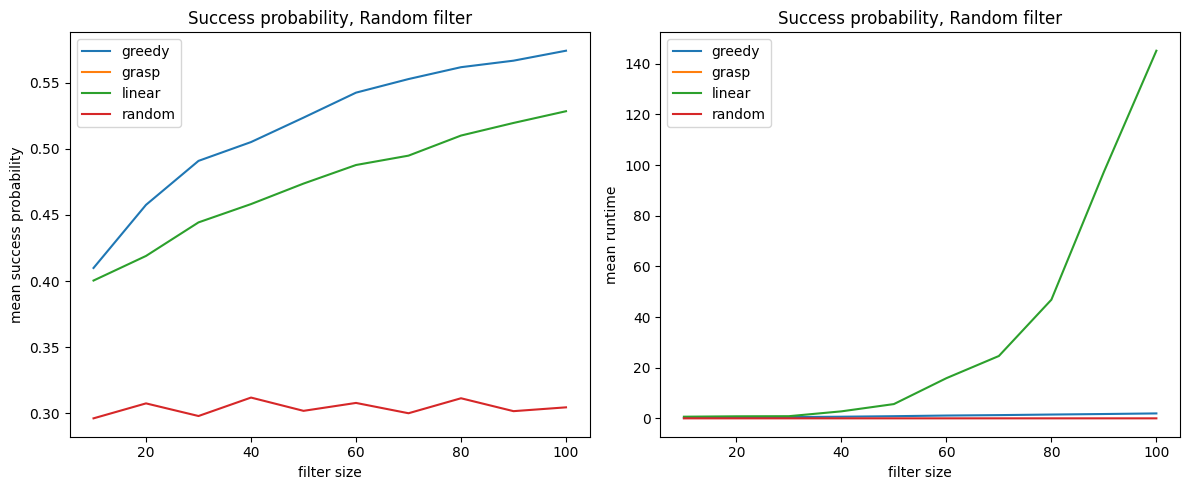

In [70]:
plt.figure(figsize=(12, 5))

include = ['greedy', 'grasp', 'linear']

plt.subplot(1,2,1)
for algo in include:
        plt.plot(random_filter_ms[algo]['filter_size'], random_filter_ms[algo]['mean_probability'], label=algo)
    
plt.legend()
plt.xlabel('filter size')
plt.ylabel('mean success probability')
plt.title('Success probability, Random filter')

plt.subplot(1,2,2)
for algo in include:
        plt.plot(random_filter_ms[algo]['filter_size'], random_filter_ms[algo]['mean_runtime'], label=algo)
    
plt.legend()
plt.xlabel('filter size')
plt.ylabel('mean runtime')
plt.title('Success probability, Random filter')

plt.tight_layout()

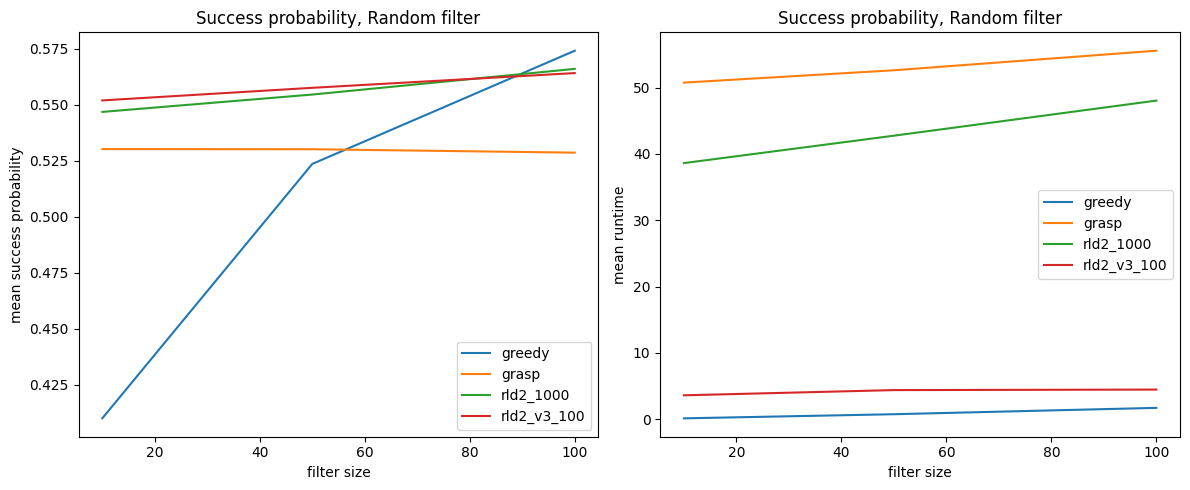

In [52]:
plt.figure(figsize=(12, 5))

include = ['greedy', 'grasp', 'rld2_1000', 'rld2_v3_100']

plt.subplot(1,2,1)
for algo in include:
        plt.plot(random_filter_ms[algo]['filter_size'], random_filter_ms[algo]['mean_probability'], label=algo)
    
plt.legend()
plt.xlabel('filter size')
plt.ylabel('mean success probability')
plt.title('Success probability, Random filter')

plt.subplot(1,2,2)
for algo in include:
        plt.plot(random_filter_ms[algo]['filter_size'], random_filter_ms[algo]['mean_runtime'], label=algo)
    
plt.legend()
plt.xlabel('filter size')
plt.ylabel('mean runtime')
plt.title('Success probability, Random filter')

plt.tight_layout()

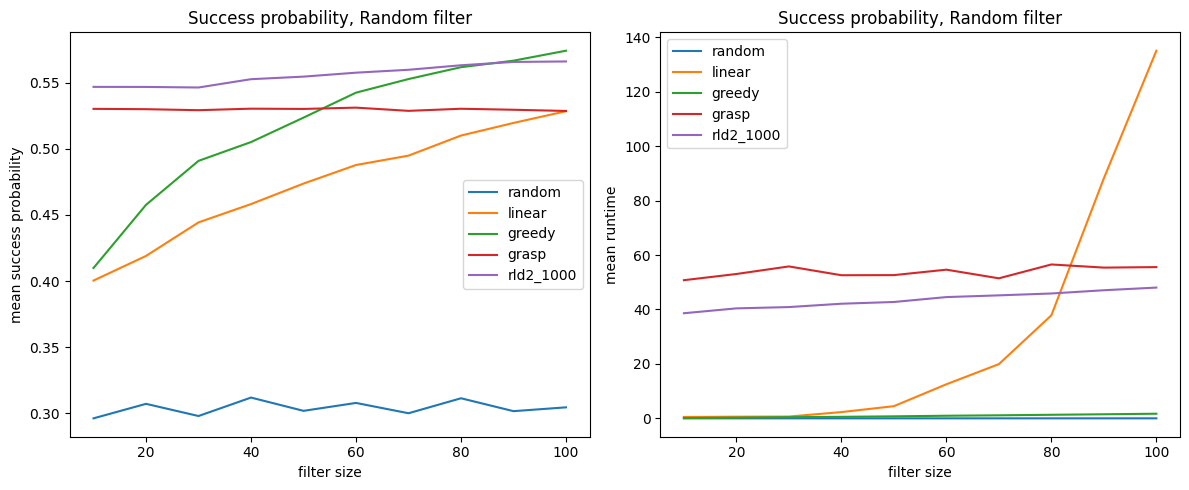

In [139]:
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
for algo in means_stds.keys():
        plt.plot(random_filter_ms[algo]['filter_size'], random_filter_ms[algo]['mean_probability'], label=algo)
    
plt.legend()
plt.xlabel('filter size')
plt.ylabel('mean success probability')
plt.title('Success probability, Random filter')

plt.subplot(1,2,2)
for algo in means_stds.keys():
        plt.plot(random_filter_ms[algo]['filter_size'], random_filter_ms[algo]['mean_runtime'], label=algo)
    
plt.legend()
plt.xlabel('filter size')
plt.ylabel('mean runtime')
plt.title('Success probability, Random filter')

plt.tight_layout()

##### ML filter:

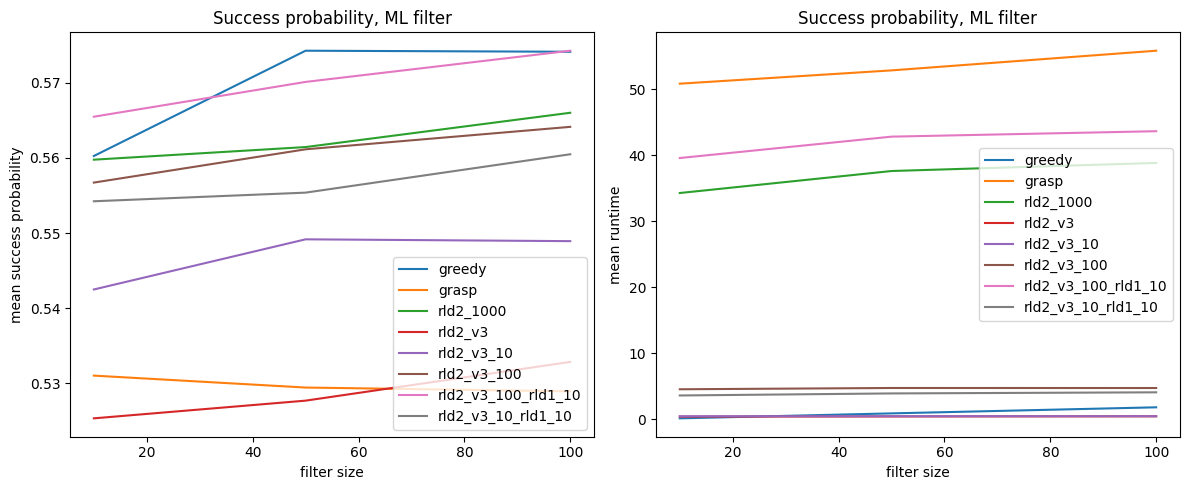

In [57]:
plt.figure(figsize=(12, 5))

include = ['greedy', 'grasp', 'rld2_1000', 'rld2_v3', 'rld2_v3_10']
include = ['greedy', 'grasp', 'rld2_1000', 'rld2_v3', 'rld2_v3_10', 'rld2_v3_100', 'rld2_v3_100_rld1_10', 'rld2_v3_10_rld1_10']
include_stoch = []

plt.subplot(1,2,1)
for algo in include:
        plt.plot(ml_filter_ms[algo]['filter_size'], ml_filter_ms[algo]['mean_probability'], label=algo)
for algo in include_stoch:
        plt.plot(stoch_rld1_ms[algo]['filter_size'], stoch_rld1_ms[algo]['mean_probability'], label=algo)
    
plt.legend()
plt.xlabel('filter size')
plt.ylabel('mean success probability')
plt.title('Success probability, ML filter')

plt.subplot(1,2,2)
for algo in include:
        plt.plot(ml_filter_ms[algo]['filter_size'], ml_filter_ms[algo]['mean_runtime'], label=algo)
for algo in include_stoch:
        plt.plot(stoch_rld1_ms[algo]['filter_size'], stoch_rld1_ms[algo]['mean_runtime'], label=algo)
   
    
plt.legend()
plt.xlabel('filter size')
plt.ylabel('mean runtime')
plt.title('Success probability, ML filter')

plt.tight_layout()

In [39]:
ml_filter_ms['rld2_v3'].mean_probability.iloc[-1] / ml_filter_ms['greedy'].mean_probability.iloc[-1]

0.9281156764901277

#### New worker_availability constraint:

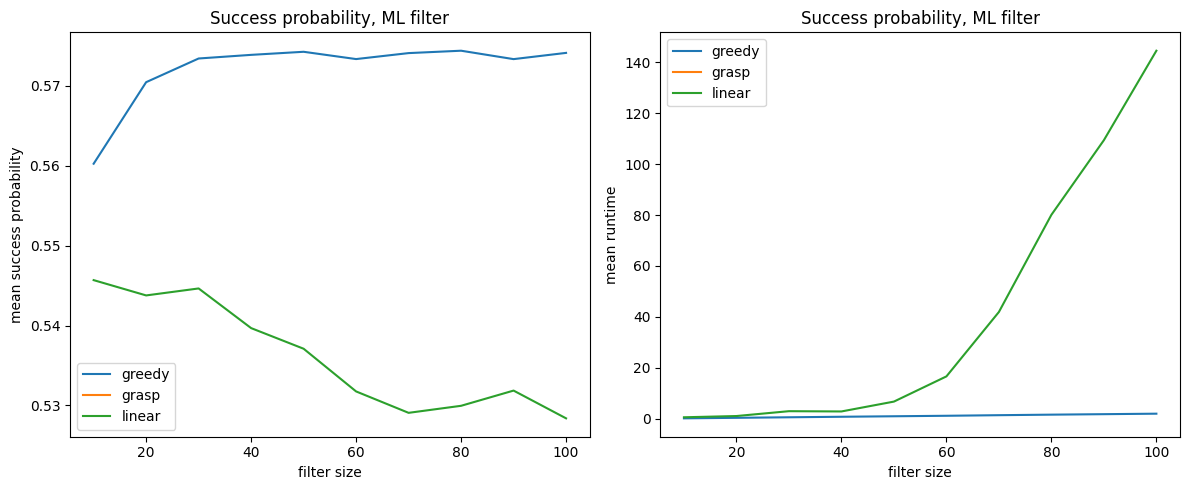

In [73]:
plt.figure(figsize=(12, 5))

include = ['greedy', 'grasp', 'linear']
include_stoch = []

plt.subplot(1,2,1)
for algo in include:
        plt.plot(ml_filter_ms[algo]['filter_size'], ml_filter_ms[algo]['mean_probability'], label=algo)
for algo in include_stoch:
        plt.plot(stoch_rld1_ms[algo]['filter_size'], stoch_rld1_ms[algo]['mean_probability'], label=algo)
    
plt.legend()
plt.xlabel('filter size')
plt.ylabel('mean success probability')
plt.title('Success probability, ML filter')

plt.subplot(1,2,2)
for algo in include:
        plt.plot(ml_filter_ms[algo]['filter_size'], ml_filter_ms[algo]['mean_runtime'], label=algo)
for algo in include_stoch:
        plt.plot(stoch_rld1_ms[algo]['filter_size'], stoch_rld1_ms[algo]['mean_runtime'], label=algo)
   
    
plt.legend()
plt.xlabel('filter size')
plt.ylabel('mean runtime')
plt.title('Success probability, ML filter')

plt.tight_layout()

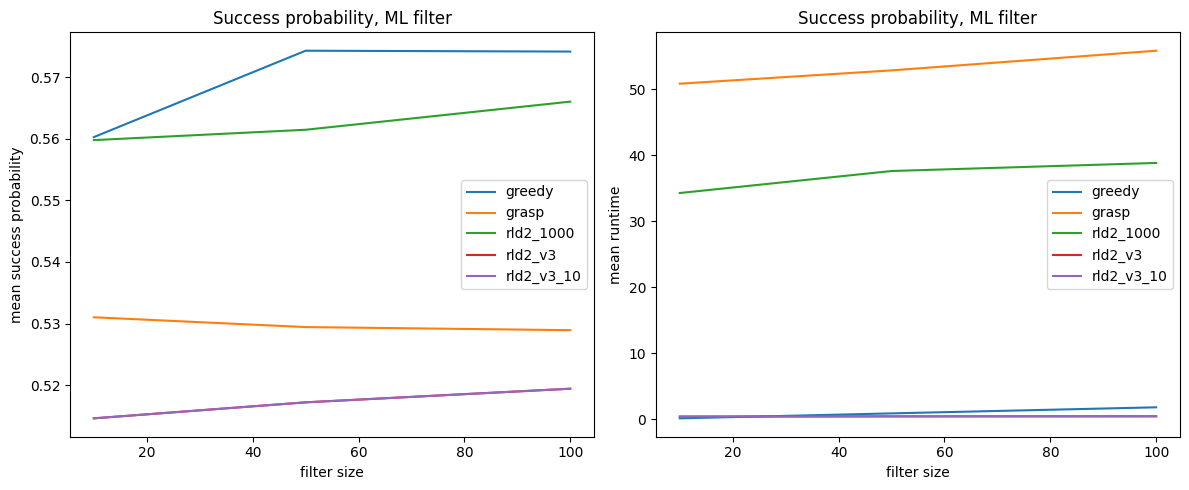

In [20]:
plt.figure(figsize=(12, 5))

include = ['greedy', 'grasp', 'rld2_1000', 'rld2_v3', 'rld2_v3_10']
include_stoch = []

plt.subplot(1,2,1)
for algo in include:
        plt.plot(ml_filter_ms[algo]['filter_size'], ml_filter_ms[algo]['mean_probability'], label=algo)
for algo in include_stoch:
        plt.plot(stoch_rld1_ms[algo]['filter_size'], stoch_rld1_ms[algo]['mean_probability'], label=algo)
    
plt.legend()
plt.xlabel('filter size')
plt.ylabel('mean success probability')
plt.title('Success probability, ML filter')

plt.subplot(1,2,2)
for algo in include:
        plt.plot(ml_filter_ms[algo]['filter_size'], ml_filter_ms[algo]['mean_runtime'], label=algo)
for algo in include_stoch:
        plt.plot(stoch_rld1_ms[algo]['filter_size'], stoch_rld1_ms[algo]['mean_runtime'], label=algo)
   
    
plt.legend()
plt.xlabel('filter size')
plt.ylabel('mean runtime')
plt.title('Success probability, ML filter')

plt.tight_layout()

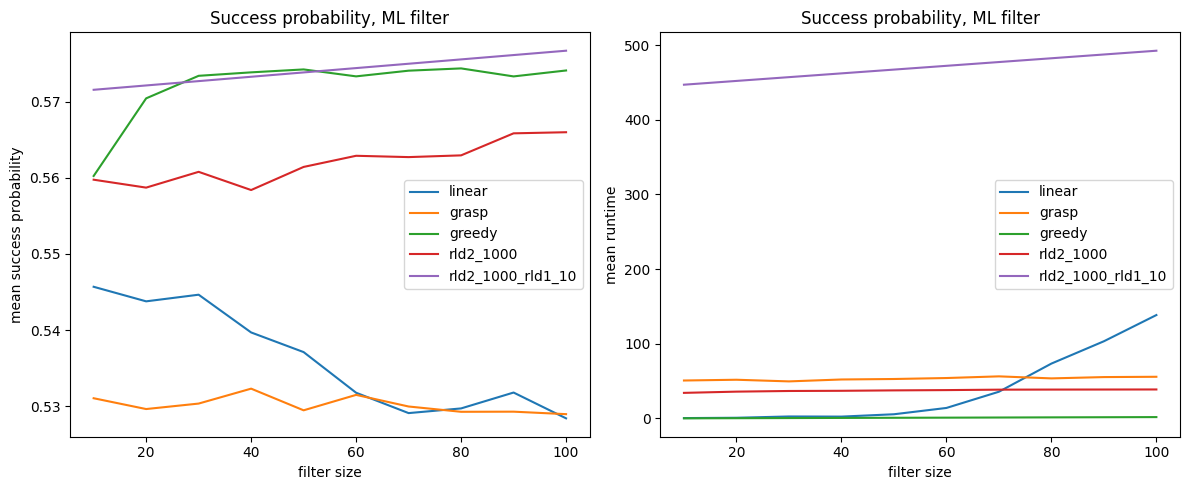

In [160]:
plt.figure(figsize=(12, 5))

# include = ['random', 'linear', 'grasp', 'greedy', 'rld2_1000']
include = ['linear', 'grasp', 'greedy', 'rld2_1000']
# include = ['linear', 'grasp', 'greedy'] # 'rld2_100', 'rld2_1000']
include_stoch = ['rld2_1000_rld1_10']#, 'rld2_10_rld1_10']

plt.subplot(1,2,1)
for algo in include:
        plt.plot(ml_filter_ms[algo]['filter_size'], ml_filter_ms[algo]['mean_probability'], label=algo)
for algo in include_stoch:
        plt.plot(stoch_rld1_ms[algo]['filter_size'], stoch_rld1_ms[algo]['mean_probability'], label=algo)
    
plt.legend()
plt.xlabel('filter size')
plt.ylabel('mean success probability')
plt.title('Success probability, ML filter')

plt.subplot(1,2,2)
for algo in include:
        plt.plot(ml_filter_ms[algo]['filter_size'], ml_filter_ms[algo]['mean_runtime'], label=algo)
for algo in include_stoch:
        plt.plot(stoch_rld1_ms[algo]['filter_size'], stoch_rld1_ms[algo]['mean_runtime'], label=algo)
   
    
plt.legend()
plt.xlabel('filter size')
plt.ylabel('mean runtime')
plt.title('Success probability, ML filter')

plt.tight_layout()

##### Stochastic RLD1

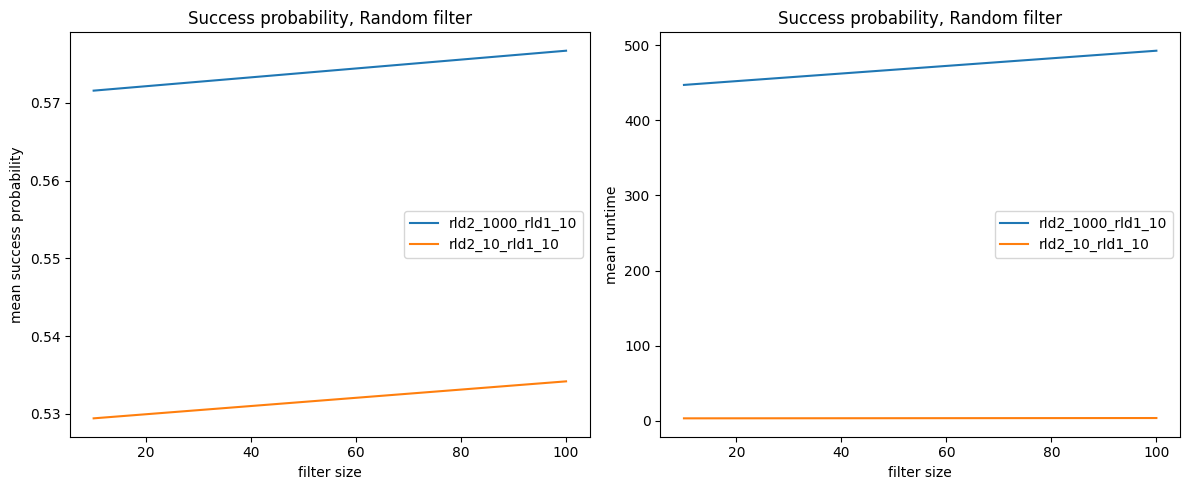

In [155]:
plt.figure(figsize=(12, 5))

include = ['rld2_1000_rld1_10', 'rld2_10_rld1_10']


plt.subplot(1,2,1)
for algo in include:
        plt.plot(stoch_rld1_ms[algo]['filter_size'], stoch_rld1_ms[algo]['mean_probability'], label=algo)
    
plt.legend()
plt.xlabel('filter size')
plt.ylabel('mean success probability')
plt.title('Success probability, Random filter')

plt.subplot(1,2,2)
for algo in include:
        plt.plot(stoch_rld1_ms[algo]['filter_size'], stoch_rld1_ms[algo]['mean_runtime'], label=algo)
    
plt.legend()
plt.xlabel('filter size')
plt.ylabel('mean runtime')
plt.title('Success probability, Random filter')

plt.tight_layout()

In [179]:
stoch_rld1_ms['rld2_1000_rld1_10']

,filter_size,mean_probability,std_probability,mean_runtime,std_runtime,mean_team_size,std_team_size
0,10,0.571587,0.095948,447.024872,186.276058,4.77,1.515619
1,100,0.576725,0.092569,492.547168,169.577476,4.94,1.548031


In [180]:
ml_filter_ms['greedy']

,filter_size,mean_probability,std_probability,mean_runtime,std_runtime,mean_team_size,std_team_size
0,10,0.560256,0.107908,0.162636,0.104321,4.45,1.558044
1,20,0.570462,0.102999,0.350249,0.217155,4.67,1.697380
2,30,0.573425,0.102442,0.540461,0.319902,4.78,1.718022
3,40,0.573880,0.102160,0.719088,0.431596,4.82,1.757157
4,50,0.574265,0.100411,0.912917,0.526857,4.92,1.770198
5,60,0.573353,0.100369,1.072267,0.586238,4.97,1.791396
6,70,0.574100,0.099731,1.268620,0.686663,4.98,1.783143
7,80,0.574399,0.098550,1.468967,0.819883,5.00,1.794436
8,90,0.573347,0.098454,1.646738,0.922200,5.01,1.791619
9,100,0.574127,0.098082,1.833431,1.015395,5.01,1.791619


### Several things are strange/unexpected:

- With random filtering, linear runtime does not scale as expected.
- With random filtering, Greedy performance does not scale as expected (at 100 workers it should be equal to ML and FirstN filter runs > 0.55).
- GRASP and RLD2 do not improve with filter size as expected - must need much greater runtime to approach better solutions as high filter sizes? CHECK.
- When does RLD2 beat Greedy/GRASP? CHECK

### Sensible observations:
- ML filter big improvement over random: see Greedy algorithm. 
- But why does it not help GRASP and RLD2? If there is a better team available there, why can't they find it? SOMETHING is wrong.

### We now grab the full state probability vector at specified filter size, to compare between algos and between filter types:

Want to test:
* Is Greedy result the same at FS=100 for both Random and ML filter? (Should be determinisitc).
* Does GRASP and RLD2 ever beat Greedy? How often and by how much?

In [44]:
def extract_raw(
    rdf, algo='random', 
    filter_sizes=[10, 20, 30, 40, 50, 60, 70, 80, 90, 100],
    fields=['probability', 'runtime', 'team_size'],
    remove_none=True
):
    print(f"Algo: {algo}")
    states = rdf[algo].keys()
    
    extract = {
        fs: {
            'state_file': [],
            'probability': [],
            'runtime': [],
            'team_size': []
        }
        for fs in filter_sizes
    }
    for fs in filter_sizes:
        for state in states:
            extract[fs]['state_file'].append(state)
    
            for field in fields:
                value = (
                    0 if (
                        len(rdf[algo][state][fs][field])==0
                        or rdf[algo][state][fs][field][0] is None
                    )
                    else rdf[algo][state][fs][field][0]
                )
                extract[fs][field].append(value)
    
    return extract
    

In [58]:
# ML Filter:
# raw_values_ml = {
#     algo: extract_raw(rdf=ml_filter_results, algo=algo)
#     for algo in ml_filter_results.keys()
# }
raw_values_ml = {
    algo: extract_raw(rdf=ml_filter_results, algo=algo, filter_sizes=[10, 50, 100])
    for algo in ml_filter_results.keys()
}

Algo: random
Algo: linear
Algo: greedy
Algo: grasp
Algo: rld2_10
Algo: rld2_100
Algo: rld2_1000
Algo: rld2_v3
Algo: rld2_v3_10
Algo: rld2_v3_100
Algo: rld2_v3_100_rld1_10
Algo: rld2_v3_10_rld1_10


In [173]:
# Random filter:
raw_values = {
    algo: extract_raw(rdf=random_filter_results, algo=algo)
    for algo in random_filter_results.keys()
}

Algo: random
Algo: linear
Algo: greedy
Algo: rld2_1000
Algo: grasp
Algo: rld2_10
Algo: rld2_100


In [174]:
# ML Filter (stochastic rld1):
rld1_stoch_raw_values_ml = {
    algo: extract_raw(rdf=stoch_rld1_results, algo=algo, filter_sizes=[10, 100])
    for algo in ['rld2_1000_rld1_10', 'rld2_10_rld1_10']
}

Algo: rld2_1000_rld1_10
Algo: rld2_10_rld1_10


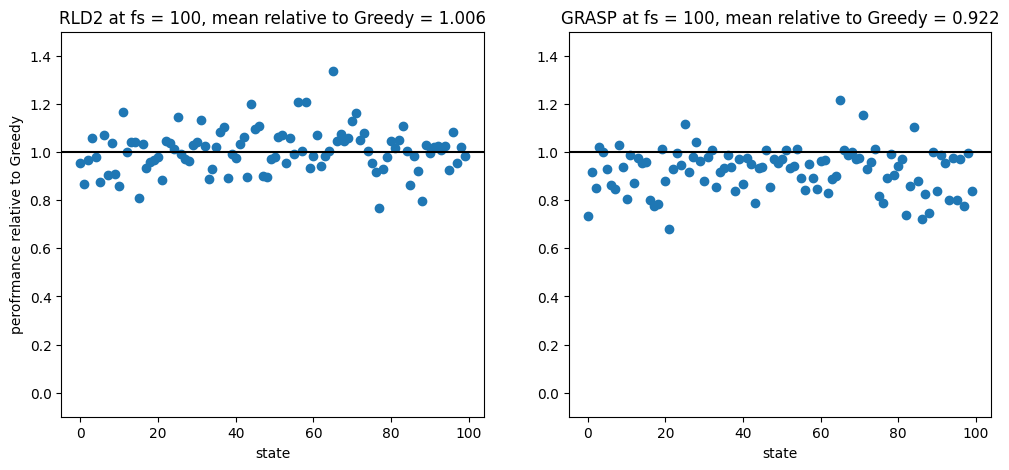

In [59]:
fs = 100
yl = [-0.1, 1.5]
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(np.arange(100), np.array(raw_values_ml['rld2_v3_100_rld1_10'][fs]['probability']) / np.array(raw_values_ml['greedy'][fs]['probability']) )
plt.axhline(1, color='k')
mean_rel = np.mean(np.array(raw_values_ml['rld2_v3_100_rld1_10'][fs]['probability']) / np.array(raw_values_ml['greedy'][fs]['probability']))
plt.title(f"RLD2 at fs = {fs}, mean relative to Greedy = {mean_rel:.3f}")
plt.xlabel('state')
plt.ylabel('perofrmance relative to Greedy')
plt.ylim(yl)

plt.subplot(1,2,2)
plt.scatter(np.arange(100), np.array(raw_values_ml['grasp'][fs]['probability']) / np.array(raw_values_ml['greedy'][fs]['probability']) )
plt.axhline(1, color='k')
mean_rel = np.mean(np.array(raw_values_ml['grasp'][fs]['probability'])/ np.array(raw_values_ml['greedy'][fs]['probability']))
plt.title(f"GRASP at fs = {fs}, mean relative to Greedy = {mean_rel:.3f}")
plt.xlabel('state')
plt.ylim(yl);

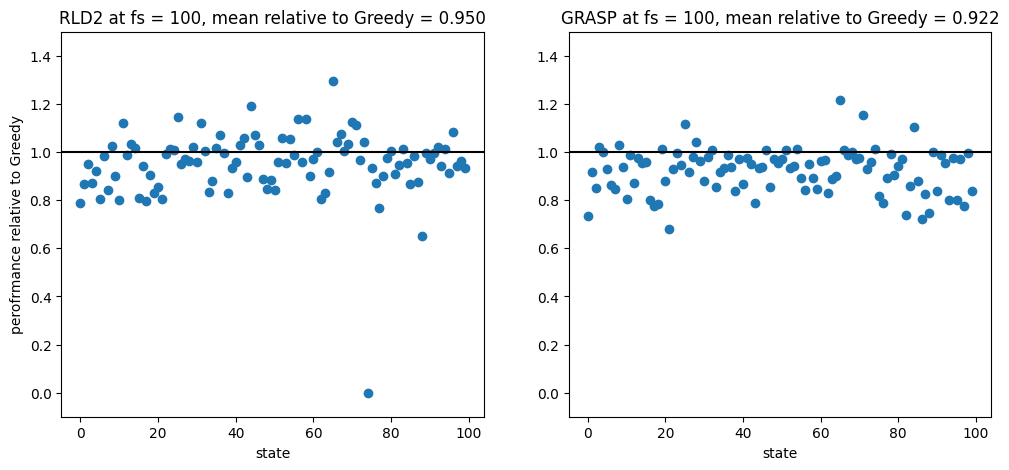

In [46]:
fs = 100
yl = [-0.1, 1.5]
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(np.arange(100), np.array(raw_values_ml['rld2_v3_10'][fs]['probability']) / np.array(raw_values_ml['greedy'][fs]['probability']) )
plt.axhline(1, color='k')
mean_rel = np.mean(np.array(raw_values_ml['rld2_v3_10'][fs]['probability']) / np.array(raw_values_ml['greedy'][fs]['probability']))
plt.title(f"RLD2 at fs = {fs}, mean relative to Greedy = {mean_rel:.3f}")
plt.xlabel('state')
plt.ylabel('perofrmance relative to Greedy')
plt.ylim(yl)

plt.subplot(1,2,2)
plt.scatter(np.arange(100), np.array(raw_values_ml['grasp'][fs]['probability']) / np.array(raw_values_ml['greedy'][fs]['probability']) )
plt.axhline(1, color='k')
mean_rel = np.mean(np.array(raw_values_ml['grasp'][fs]['probability'])/ np.array(raw_values_ml['greedy'][fs]['probability']))
plt.title(f"GRASP at fs = {fs}, mean relative to Greedy = {mean_rel:.3f}")
plt.xlabel('state')
plt.ylim(yl);

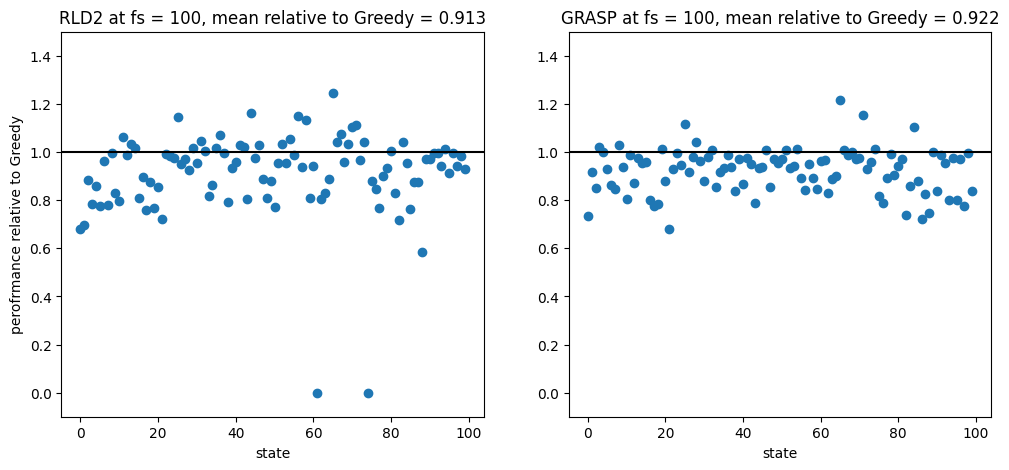

In [47]:
fs = 100
yl = [-0.1, 1.5]
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(np.arange(100), np.array(raw_values_ml['rld2_v3'][fs]['probability']) / np.array(raw_values_ml['greedy'][fs]['probability']) )
plt.axhline(1, color='k')
mean_rel = np.mean(np.array(raw_values_ml['rld2_v3'][fs]['probability']) / np.array(raw_values_ml['greedy'][fs]['probability']))
plt.title(f"RLD2 at fs = {fs}, mean relative to Greedy = {mean_rel:.3f}")
plt.xlabel('state')
plt.ylabel('perofrmance relative to Greedy')
plt.ylim(yl)

plt.subplot(1,2,2)
plt.scatter(np.arange(100), np.array(raw_values_ml['grasp'][fs]['probability']) / np.array(raw_values_ml['greedy'][fs]['probability']) )
plt.axhline(1, color='k')
mean_rel = np.mean(np.array(raw_values_ml['grasp'][fs]['probability'])/ np.array(raw_values_ml['greedy'][fs]['probability']))
plt.title(f"GRASP at fs = {fs}, mean relative to Greedy = {mean_rel:.3f}")
plt.xlabel('state')
plt.ylim(yl);

In [61]:
for state in ml_filter_results['rld2_v3'].jeys():
    

{'state_10.pickle': {10: {'probability': [0.23584969561265998],
   'runtime': [0.38195061683654785],
   'team_size': [5],
   'solution': [<superscript_abm.optimisation_decoupled.Solution at 0x7f6b35b017e0>]},
  50: {'probability': [0.23621111800777506],
   'runtime': [0.3852875232696533],
   'team_size': [3],
   'solution': [<superscript_abm.optimisation_decoupled.Solution at 0x7f6b343f2800>]},
  100: {'probability': [0.2575132593492948],
   'runtime': [0.40181875228881836],
   'team_size': [5],
   'solution': [<superscript_abm.optimisation_decoupled.Solution at 0x7f6b3a778130>]}},
 'state_32.pickle': {10: {'probability': [0.4110871334069944],
   'runtime': [0.42755746841430664],
   'team_size': [3],
   'solution': [<superscript_abm.optimisation_decoupled.Solution at 0x7f6b3a7783a0>]},
  50: {'probability': [0.38758669665122164],
   'runtime': [0.41231465339660645],
   'team_size': [5],
   'solution': [<superscript_abm.optimisation_decoupled.Solution at 0x7f6b3cfc9db0>]},
  100: {'prob

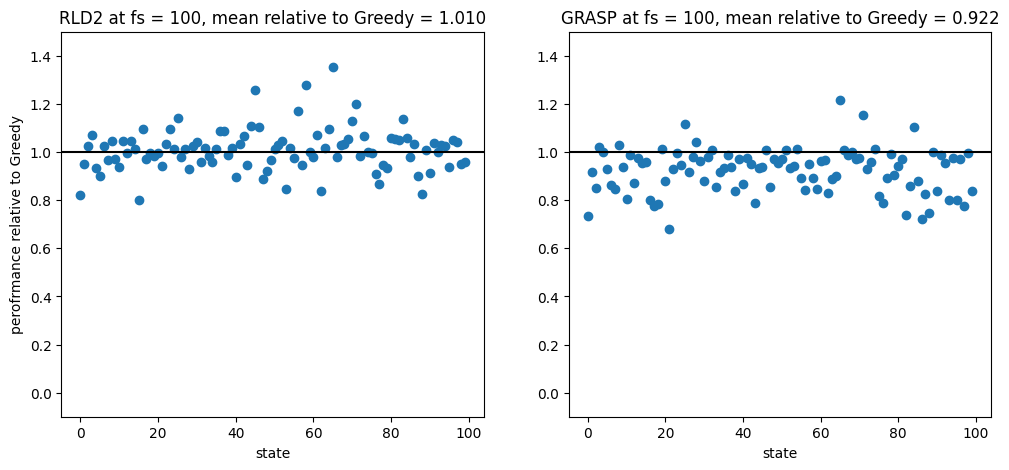

In [183]:
fs = 100
yl = [-0.1, 1.5]
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(np.arange(100), np.array(rld1_stoch_raw_values_ml['rld2_1000_rld1_10'][fs]['probability']) / np.array(raw_values_ml['greedy'][fs]['probability']) )
plt.axhline(1, color='k')
mean_rel = np.mean(np.array(rld1_stoch_raw_values_ml['rld2_1000_rld1_10'][fs]['probability']) / np.array(raw_values_ml['greedy'][fs]['probability']))
plt.title(f"RLD2 at fs = {fs}, mean relative to Greedy = {mean_rel:.3f}")
plt.xlabel('state')
plt.ylabel('perofrmance relative to Greedy')
plt.ylim(yl)

plt.subplot(1,2,2)
plt.scatter(np.arange(100), np.array(raw_values_ml['grasp'][fs]['probability']) / np.array(raw_values_ml['greedy'][fs]['probability']) )
plt.axhline(1, color='k')
mean_rel = np.mean(np.array(raw_values_ml['grasp'][fs]['probability'])/ np.array(raw_values_ml['greedy'][fs]['probability']))
plt.title(f"GRASP at fs = {fs}, mean relative to Greedy = {mean_rel:.3f}")
plt.xlabel('state')
plt.ylim(yl);

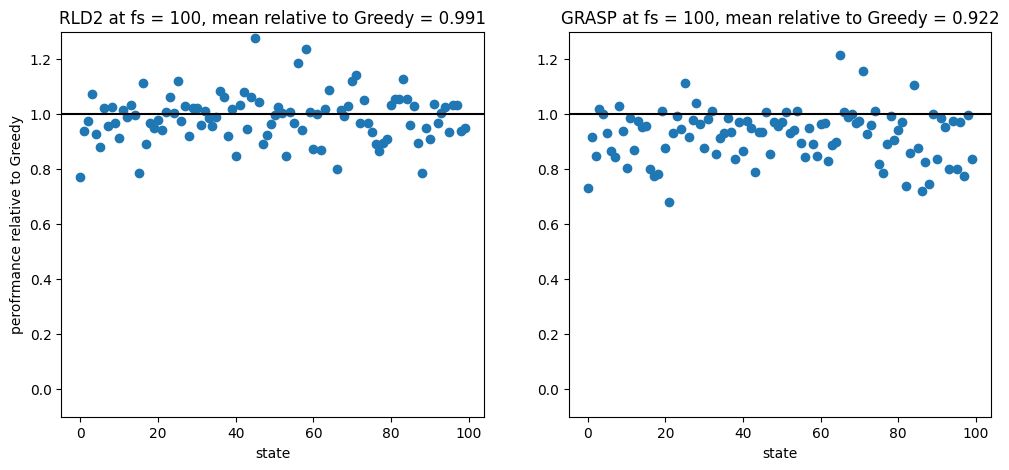

In [21]:
fs = 100
yl = [-0.1, 1.3]
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(np.arange(100), np.array(new_raw_values_ml['rld2_1000'][fs]['probability']) / np.array(raw_values_ml['greedy'][fs]['probability']) )
plt.axhline(1, color='k')
mean_rel = np.mean(np.array(new_raw_values_ml['rld2_1000'][fs]['probability']) / np.array(raw_values_ml['greedy'][fs]['probability']))
plt.title(f"RLD2 at fs = {fs}, mean relative to Greedy = {mean_rel:.3f}")
plt.xlabel('state')
plt.ylabel('perofrmance relative to Greedy')
plt.ylim(yl)

plt.subplot(1,2,2)
plt.scatter(np.arange(100), np.array(raw_values_ml['grasp'][fs]['probability']) / np.array(raw_values_ml['greedy'][fs]['probability']) )
plt.axhline(1, color='k')
mean_rel = np.mean(np.array(raw_values_ml['grasp'][fs]['probability'])/ np.array(raw_values_ml['greedy'][fs]['probability']))
plt.title(f"GRASP at fs = {fs}, mean relative to Greedy = {mean_rel:.3f}")
plt.xlabel('state')
plt.ylim(yl);

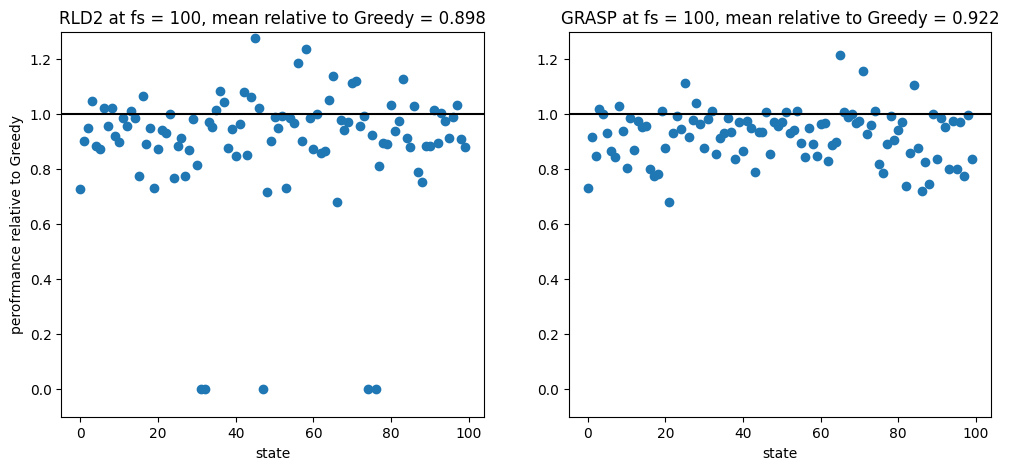

In [163]:
fs = 100
yl = [-0.1, 1.3]
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(np.arange(100), np.array(raw_values_ml['rld2_1000'][fs]['probability']) / np.array(raw_values_ml['greedy'][fs]['probability']) )
plt.axhline(1, color='k')
mean_rel = np.mean(np.array(raw_values_ml['rld2_1000'][fs]['probability']) / np.array(raw_values_ml['greedy'][fs]['probability']))
plt.title(f"RLD2 at fs = {fs}, mean relative to Greedy = {mean_rel:.3f}")
plt.xlabel('state')
plt.ylabel('perofrmance relative to Greedy')
plt.ylim(yl)

plt.subplot(1,2,2)
plt.scatter(np.arange(100), np.array(raw_values_ml['grasp'][fs]['probability']) / np.array(raw_values_ml['greedy'][fs]['probability']) )
plt.axhline(1, color='k')
mean_rel = np.mean(np.array(raw_values_ml['grasp'][fs]['probability'])/ np.array(raw_values_ml['greedy'][fs]['probability']))
plt.title(f"GRASP at fs = {fs}, mean relative to Greedy = {mean_rel:.3f}")
plt.xlabel('state')
plt.ylim(yl);

In [168]:
probability_mat = np.zeros([7, 100])

In [169]:
for ai, algo in enumerate(raw_values_ml.keys()):
    probability_mat[ai,:] = raw_values_ml[algo][fs]['probability']

<Figure size 3000x1000 with 0 Axes>

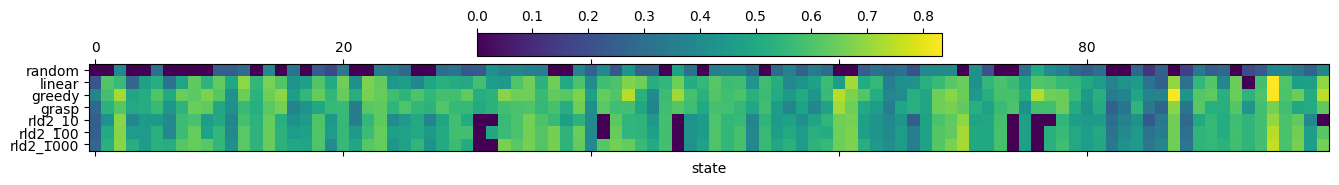

In [188]:
plt.figure(figsize=(30,10));
plt.matshow(probability_mat)
plt.colorbar(orientation='horizontal', location='top')
plt.yticks(ticks=range(7), labels=raw_values_ml.keys())
plt.xlabel('state');
# plt.ylabel('algorithm');